In [1]:
import pandas as pd
import numpy as np
np.set_printoptions(threshold=10000, linewidth=10000)
import sklearn
import matplotlib.pyplot as plt

In [2]:
'''write train data to csv, with output column'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/train/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #correct strings
    temp_df.T2_data = temp_df.T2_data.str.replace(",",".")
    temp_df.T2_data = temp_df.T2_data.str.replace(" ","").astype(float)#/1000
    #clip at zero
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    #add row with contents of current file
    array = np.vstack((array,temp_df.T2_data))

# scaler = sklearn.preprocessing.MinMaxScaler()
# array = scaler.fit_transform(array.T).T
train_df = pd.DataFrame(array)

#adding y column to df
train_df['y'] = pd.read_csv("../RMN/train/Output/OilSat.csv", sep="\t")['Oil_Sat']

#writing to csv file
# train_df.to_csv("./data_train.csv", sep="\t", index=False)
train_df

,0,1,2,3,4,5,6,7,8,9,...,2192,2193,2194,2195,2196,2197,2198,2199,2200,y
0,808.799082,761.492786,806.187443,720.554460,721.984355,798.494023,783.867886,703.372500,737.758637,677.632094,...,0.000000,0.000000,4.560319,0.000000,0.000000,35.802022,18.476682,0.000000,56.427370,0.29
1,806.848854,772.155536,768.036560,742.568014,799.491620,779.938222,764.711275,784.916453,762.177924,670.400000,...,0.000000,2.426548,53.201190,26.355047,20.801370,0.000000,0.000000,0.000000,47.609466,0.30
2,730.200000,792.757589,776.700000,751.077526,723.304830,771.900000,695.949775,648.200703,691.083328,829.489933,...,60.111685,9.801082,18.689186,0.000000,62.865400,0.000000,0.000000,18.137485,0.000000,0.11
3,821.096896,739.546492,792.518898,851.488126,745.911082,847.673447,716.392011,636.216770,679.300000,668.267946,...,11.160737,22.608489,5.721154,12.793747,6.062400,0.000000,0.000000,25.047053,0.000000,0.61
4,735.200000,767.431469,896.210757,784.622258,787.817844,702.942107,768.784863,679.843566,784.000000,699.595983,...,0.000000,2.610422,0.000000,0.000000,17.710079,0.000000,9.771761,0.000000,8.674025,0.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,714.406117,793.136695,853.718918,758.564529,697.461902,750.200000,722.200000,734.151744,718.378305,733.320000,...,0.000000,0.000000,5.461014,0.000000,0.000000,53.820438,77.203931,39.231717,23.820588,0.33
996,780.313950,815.668300,823.914763,781.077670,844.040867,750.356323,631.812091,715.618529,687.206558,704.000000,...,0.000000,3.709000,0.000000,80.340000,0.000000,0.000000,55.730000,75.731452,0.000000,0.29
997,854.829787,726.189085,684.060652,764.558238,745.292436,711.783100,768.798227,756.263238,646.471785,688.600000,...,29.573043,52.929646,43.284687,0.000000,0.000000,2.788000,0.000000,0.000000,25.699377,0.36
998,806.600000,846.161381,809.100000,737.104861,804.577558,709.785240,674.010744,732.280491,678.859135,658.797211,...,12.950000,44.666910,72.717629,4.801789,50.421500,0.000000,0.000000,43.950000,13.294910,0.69


In [3]:
'''write test data to csv'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/test/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #for test, no text correction, no clipping
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    array = np.vstack((array,temp_df.T2_data))
# array = scaler.fit_transform(array.T).T
test_df = pd.DataFrame(array)
# test_df.to_csv("./data_test.csv", sep="\t", index=False)
test_df

,0,1,2,3,4,5,6,7,8,9,...,2191,2192,2193,2194,2195,2196,2197,2198,2199,2200
0,0.788302,0.833668,0.777146,0.819389,0.861003,0.807070,0.821894,0.811667,0.827137,0.796143,...,0.011400,0.095998,0.042935,0.045150,0.005347,0.042562,0.011324,0.016268,0.037239,0.000000
1,0.884277,0.864711,0.746354,0.786617,0.749206,0.736673,0.753945,0.791456,0.732960,0.744620,...,0.084529,0.010721,0.048491,0.001737,0.009000,0.054540,0.000000,0.000000,0.067455,0.000000
2,0.899784,0.774386,0.864490,0.895171,0.822695,0.785098,0.814283,0.804869,0.853816,0.828943,...,0.000000,0.000000,0.000000,0.042150,0.036852,0.010074,0.000000,0.000000,0.043007,0.000000
3,0.872215,0.913709,0.742457,0.813629,0.796481,0.763009,0.777455,0.696683,0.719256,0.806203,...,0.026313,0.010141,0.026126,0.003622,0.031001,0.062767,0.000000,0.046767,0.056365,0.046251
4,0.849244,0.797369,0.818437,0.764594,0.704282,0.759954,0.744396,0.750625,0.772093,0.712152,...,0.114391,0.013762,0.039784,0.002855,0.008673,0.042258,0.037005,0.000000,0.076023,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.825135,0.906567,0.823369,0.802071,0.890256,0.875190,0.804806,0.784156,0.792596,0.789138,...,0.000000,0.043368,0.000000,0.000000,0.044434,0.000000,0.002551,0.035874,0.000000,0.000101
996,0.851421,0.871547,0.856086,0.793908,0.768383,0.724346,0.717519,0.731956,0.813253,0.761697,...,0.011083,0.004423,0.053659,0.001334,0.000000,0.022779,0.000000,0.000000,0.000000,0.142307
997,0.924303,0.849955,0.905681,0.789871,0.823404,0.858669,0.795157,0.730247,0.719397,0.791538,...,0.083239,0.000000,0.010731,0.000000,0.000000,0.093162,0.072633,0.008447,0.039745,0.000000
998,0.871070,0.831418,0.888724,0.844934,0.819290,0.826558,0.804389,0.707092,0.745585,0.763603,...,0.072051,0.014275,0.035158,0.068349,0.123871,0.000000,0.036660,0.000000,0.000000,0.000000


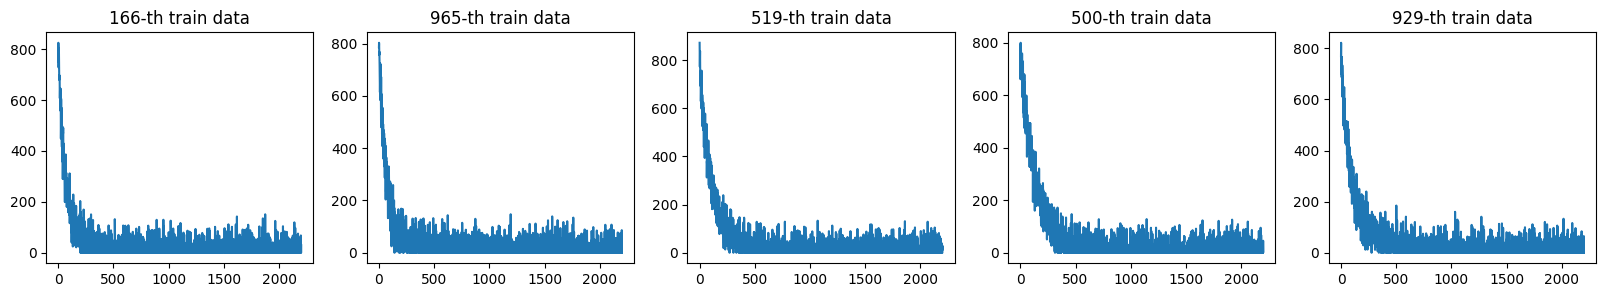

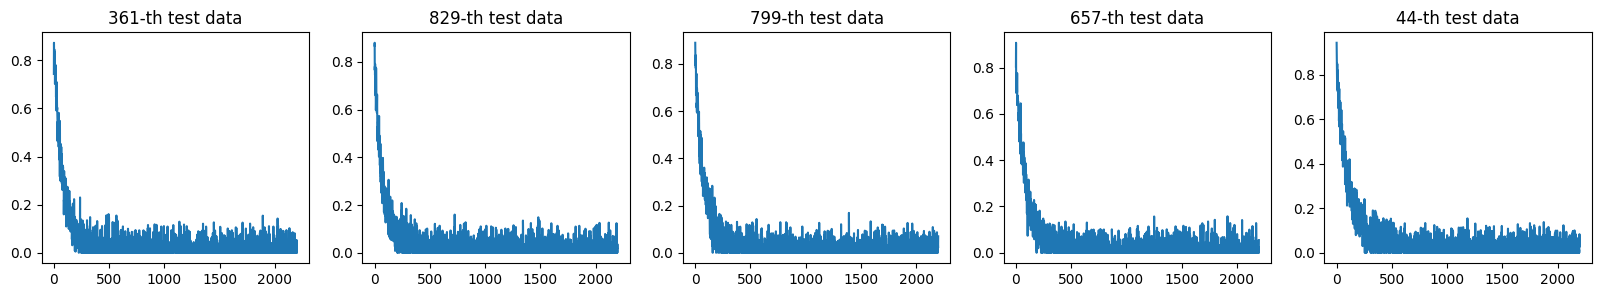

In [4]:
'''Plot graph of test and train after clip and normalization for comparison'''
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th test data")
plt.show();

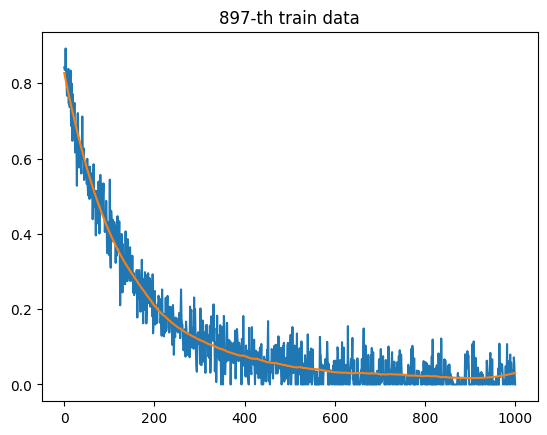

In [6]:
import scipy as sp
from scipy.signal import savgol_filter

j = np.random.randint(1,1000,1)[0]
# signal = train_df.drop('y',axis=1).loc[j,:1000]
signal = train_df.loc[j,:1000]
plt.plot(signal)
window_length, polyorder = 271, 3
plt.plot(savgol_filter(signal, window_length, polyorder))
plt.title(str(j)+"-th train data");

In [9]:
scaler = sklearn.preprocessing.MinMaxScaler()
window_length, polyorder = 271, 3


array = np.array(train_df.drop('y',axis=1))
savgol_array = np.zeros((0,2201))
for i in range(len(train_df)):
    row = savgol_filter(array[i], window_length, polyorder)
    savgol_array = np.vstack((savgol_array,row))
savgol_array = scaler.fit_transform(savgol_array.T).T
train_savgol_df = pd.DataFrame(savgol_array)

array = np.array(test_df)
savgol_array = np.zeros((0,2201))
for i in range(len(test_df)):
    row = savgol_filter(array[i], window_length, polyorder)
    savgol_array = np.vstack((savgol_array,row))
savgol_array = scaler.fit_transform(savgol_array.T).T
test_savgol_df = pd.DataFrame(savgol_array)

train_savgol_df.shape, test_savgol_df.shape

((1000, 2201), (1000, 2201))

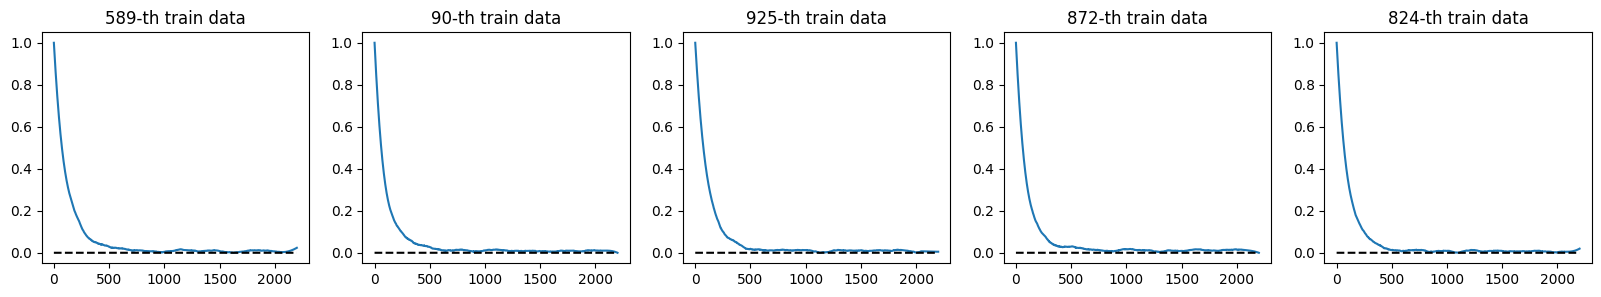

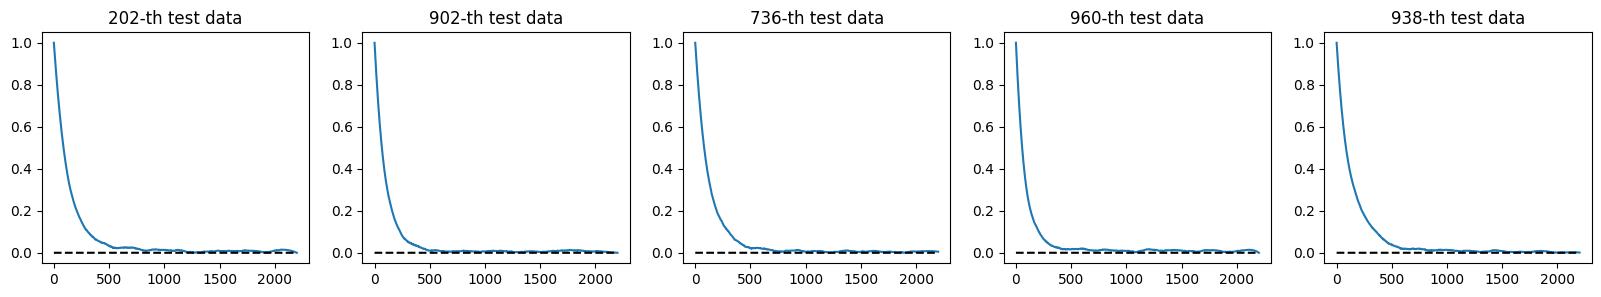

In [11]:
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_savgol_df.loc[j].values)
    ax[i].set_title(f"{j}-th train data")
    ax[i].plot([0]*train_savgol_df.shape[1],'k--')
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_savgol_df .loc[j].values)
    ax[i].set_title(f"{j}-th test data")
    ax[i].plot([0]*test_savgol_df.shape[1],'k--')
plt.show();

Salvando um arquivo com os primeiros 700 pontos de cada curva:

In [12]:
train_savgol_df = train_savgol_df.iloc[:,:700]
train_savgol_df['y'] = train_df['y']
train_savgol_df.to_csv('data_train_post_n_savgol.csv', sep='\t', index=False)

test_savgol_df  = test_savgol_df.iloc[:,:700]
test_savgol_df.to_csv('data_test_post_n_savgol.csv', sep='\t', index=False)